### English FPL 2003/2004 Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Python
prem = pd.read_csv('Prem0304.csv', quotechar='"', quoting=0, on_bad_lines='skip')
prem.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,B365<2.5,GBAHH,GBAHA,GBAH,LBAHH,LBAHA,LBAH,B365AHH,B365AHA,B365AH
0,E0,16/08/03,Arsenal,Everton,2,1,H,1,0,H,...,2.10,1.90,1.90,-1.25,1.90,1.95,-1.25,1.975,1.925,-1.25
1,E0,16/08/03,Birmingham,Tottenham,1,0,H,1,0,H,...,1.85,2.05,1.75,-0.25,1.75,2.10,0.00,2.100,1.800,-0.25
2,E0,16/08/03,Blackburn,Wolves,5,1,H,2,0,H,...,1.90,1.95,1.85,-0.75,2.00,1.85,-0.75,1.950,1.950,-0.75
3,E0,16/08/03,Fulham,Middlesbrough,3,2,H,1,1,D,...,1.70,1.80,2.00,0.00,1.85,2.00,0.00,2.100,1.800,-0.25
4,E0,16/08/03,Leicester,Southampton,2,2,D,2,0,H,...,1.80,1.85,1.95,0.00,1.85,2.00,0.00,1.850,2.050,0.00


In [3]:
prem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 57 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Div       335 non-null    object 
 1   Date      335 non-null    object 
 2   HomeTeam  335 non-null    object 
 3   AwayTeam  335 non-null    object 
 4   FTHG      335 non-null    int64  
 5   FTAG      335 non-null    int64  
 6   FTR       335 non-null    object 
 7   HTHG      335 non-null    int64  
 8   HTAG      335 non-null    int64  
 9   HTR       335 non-null    object 
 10  Referee   335 non-null    object 
 11  HS        335 non-null    int64  
 12  AS        335 non-null    int64  
 13  HST       335 non-null    int64  
 14  AST       335 non-null    int64  
 15  HF        335 non-null    int64  
 16  AF        335 non-null    int64  
 17  HC        335 non-null    int64  
 18  AC        335 non-null    int64  
 19  HY        335 non-null    int64  
 20  AY        335 non-null    int64 

In [4]:
prem.shape  

(335, 57)

## Team Performance Analysis

Analysis of the performance of each team in the 2003/2004 Premier League season. Calculated league table, including points, wins, draws, losses, and compare home vs. away performance.

In [5]:
# Calculate points for home and away teams
# Assumes columns: 'HomeTeam', 'AwayTeam', 'FTHG' (home goals), 'FTAG' (away goals), 'FTR' (full time result: H/D/A)

# Calculate home points
home = prem.groupby('HomeTeam').agg(
    HomePlayed = ('HomeTeam', 'count'),
    HomeWins = ('FTR', lambda x: (x == 'H').sum()),
    HomeDraws = ('FTR', lambda x: (x == 'D').sum()),
    HomeLosses = ('FTR', lambda x: (x == 'A').sum()),
    HomeGoalsFor = ('FTHG', 'sum'),
    HomeGoalsAgainst = ('FTAG', 'sum')
)
home['HomePoints'] = home['HomeWins']*3 + home['HomeDraws']

# Calculate away points
away = prem.groupby('AwayTeam').agg(
    AwayPlayed = ('AwayTeam', 'count'),
    AwayWins = ('FTR', lambda x: (x == 'A').sum()),
    AwayDraws = ('FTR', lambda x: (x == 'D').sum()),
    AwayLosses = ('FTR', lambda x: (x == 'H').sum()),
    AwayGoalsFor = ('FTAG', 'sum'),
    AwayGoalsAgainst = ('FTHG', 'sum')
)
away['AwayPoints'] = away['AwayWins']*3 + away['AwayDraws']

# Combine home and away
league = home.join(away, how='outer')
league['Played'] = league['HomePlayed'] + league['AwayPlayed']
league['Wins'] = league['HomeWins'] + league['AwayWins']
league['Draws'] = league['HomeDraws'] + league['AwayDraws']
league['Losses'] = league['HomeLosses'] + league['AwayLosses']
league['GoalsFor'] = league['HomeGoalsFor'] + league['AwayGoalsFor']
league['GoalsAgainst'] = league['HomeGoalsAgainst'] + league['AwayGoalsAgainst']
league['GoalDiff'] = league['GoalsFor'] - league['GoalsAgainst']
league['Points'] = league['HomePoints'] + league['AwayPoints']

# Sort by points, then goal difference, then goals for
league_table = league.sort_values(['Points', 'GoalDiff', 'GoalsFor'], ascending=False)
league_table[['Played','Wins','Draws','Losses','GoalsFor','GoalsAgainst','GoalDiff','Points','HomePoints','AwayPoints']]

,Played,Wins,Draws,Losses,GoalsFor,GoalsAgainst,GoalDiff,Points,HomePoints,AwayPoints
HomeTeam,,,,,,,,,,
Arsenal,33,22,11,0,61,23,38,77,40,37
Chelsea,33,22,5,6,63,27,36,71,35,36
Man United,34,20,6,8,59,33,26,66,37,29
Liverpool,33,15,10,8,48,31,17,55,29,26
Newcastle,34,13,13,8,47,35,12,52,36,16
Aston Villa,34,14,9,11,42,37,5,51,29,22
Birmingham,34,12,12,10,39,41,-2,48,29,19
Bolton,34,12,10,12,42,51,-9,46,22,24
Fulham,33,12,9,12,45,41,4,45,31,14


### Points Progression of Top 5 Teams

Let's visualize how the points accumulated over the season for the top 5 teams in the final league table.

C:\Users\laura\AppData\Local\Temp\ipykernel_24220\3636134532.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  matches['Date'] = pd.to_datetime(matches['Date'])


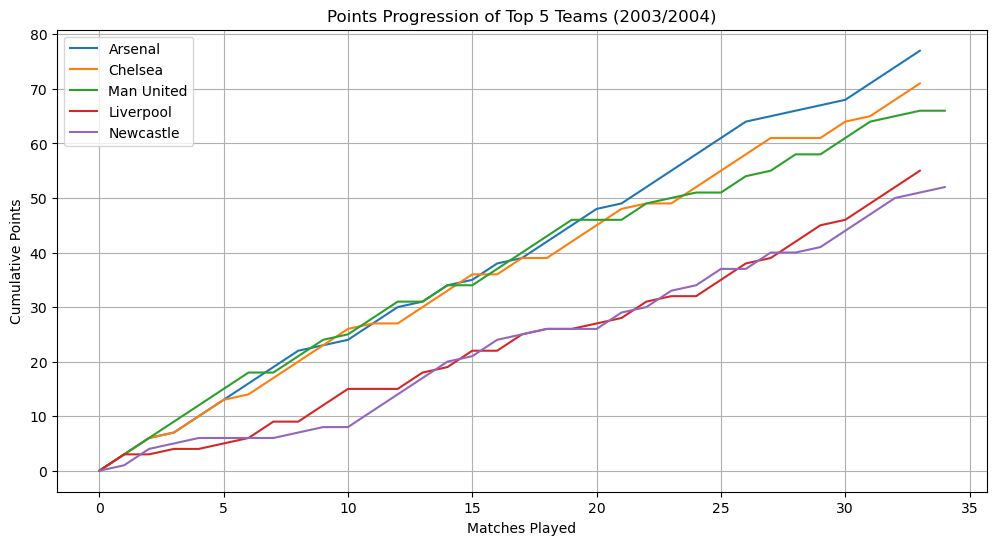

In [6]:
# Get top 5 teams from final league table
# (Assumes 'league_table' is already calculated in previous cell)
top5_teams = league_table.head(5).index.tolist()

# Prepare a DataFrame to track cumulative points for each team after each match
matches = prem.copy()
matches['Date'] = pd.to_datetime(matches['Date'])
matches = matches.sort_values('Date')

# Initialize points progression dict
points_progression = {team: [0] for team in top5_teams}
match_counts = {team: [0] for team in top5_teams}

# Track points after each match for each top 5 team
for i, row in matches.iterrows():
    for team in top5_teams:
        # Copy last value
        points_progression[team].append(points_progression[team][-1])
        match_counts[team].append(match_counts[team][-1])
    # Home team
    if row['HomeTeam'] in top5_teams:
        if row['FTR'] == 'H':
            points_progression[row['HomeTeam']][-1] += 3
        elif row['FTR'] == 'D':
            points_progression[row['HomeTeam']][-1] += 1
        match_counts[row['HomeTeam']][-1] += 1
    # Away team
    if row['AwayTeam'] in top5_teams:
        if row['FTR'] == 'A':
            points_progression[row['AwayTeam']][-1] += 3
        elif row['FTR'] == 'D':
            points_progression[row['AwayTeam']][-1] += 1
        match_counts[row['AwayTeam']][-1] += 1

# Remove the initial zero (for plotting)
for team in top5_teams:
    points_progression[team] = points_progression[team][1:]
    match_counts[team] = match_counts[team][1:]

# Plot
plt.figure(figsize=(12,6))
for team in top5_teams:
    plt.plot(match_counts[team], points_progression[team], label=team)
plt.xlabel('Matches Played')
plt.ylabel('Cumulative Points')
plt.title('Points Progression of Top 5 Teams (2003/2004)')
plt.legend()
plt.grid(True)
plt.show()

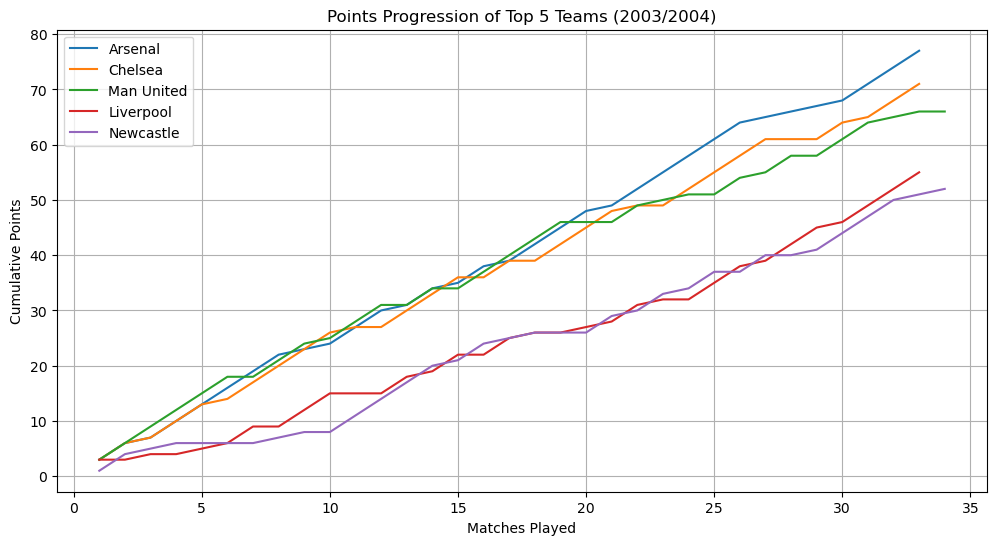

In [7]:
# Points progression for top 5 teams (each line reaches 38 matches)
plt.figure(figsize=(12,6))
for team in top5_teams:
    # Get all matches for this team, sorted by date
    team_matches = matches[(matches['HomeTeam'] == team) | (matches['AwayTeam'] == team)].sort_values('Date')
    points = [0]
    for _, row in team_matches.iterrows():
        if row['HomeTeam'] == team:
            if row['FTR'] == 'H':
                points.append(points[-1] + 3)
            elif row['FTR'] == 'D':
                points.append(points[-1] + 1)
            else:
                points.append(points[-1])
        else:  # Away
            if row['FTR'] == 'A':
                points.append(points[-1] + 3)
            elif row['FTR'] == 'D':
                points.append(points[-1] + 1)
            else:
                points.append(points[-1])
    # Remove initial zero for plotting
    plt.plot(range(1, len(points)), points[1:], label=team)
plt.xlabel('Matches Played')
plt.ylabel('Cumulative Points')
plt.title('Points Progression of Top 5 Teams (2003/2004)')
plt.legend()
plt.grid(True)
plt.show()

### Streaks: Longest Winning, Losing, and Unbeaten Runs

This section calculates the longest winning, losing, and unbeaten streaks for each team in the 2003/2004 season.

In [8]:
def get_streaks(results, streak_type):
    max_streak = 0
    current = 0
    for r in results:
        if streak_type == 'win' and r == 'W':
            current += 1
        elif streak_type == 'lose' and r == 'L':
            current += 1
        elif streak_type == 'unbeaten' and r in ['W', 'D']:
            current += 1
        else:
            current = 0
        if current > max_streak:
            max_streak = current
    return max_streak

# Prepare results for each team
team_streaks = {}
for team in league_table.index:
    # Get all matches for this team, sorted by date
    team_matches = matches[(matches['HomeTeam'] == team) | (matches['AwayTeam'] == team)].sort_values('Date')
    results = []
    for _, row in team_matches.iterrows():
        if row['HomeTeam'] == team:
            if row['FTR'] == 'H':
                results.append('W')
            elif row['FTR'] == 'D':
                results.append('D')
            else:
                results.append('L')
        else:  # Away
            if row['FTR'] == 'A':
                results.append('W')
            elif row['FTR'] == 'D':
                results.append('D')
            else:
                results.append('L')
    team_streaks[team] = {
        'Longest Win Streak': get_streaks(results, 'win'),
        'Longest Lose Streak': get_streaks(results, 'lose'),
        'Longest Unbeaten Streak': get_streaks(results, 'unbeaten')
    }

import pandas as pd
streaks_df = pd.DataFrame(team_streaks).T.sort_values('Longest Win Streak', ascending=False)
print('Longest Streaks by Team:')
display(streaks_df)

# Show the teams with the longest streaks overall
print('Team(s) with Longest Winning Streak:')
display(streaks_df[streaks_df['Longest Win Streak'] == streaks_df['Longest Win Streak'].max()])
print('Team(s) with Longest Losing Streak:')
display(streaks_df[streaks_df['Longest Lose Streak'] == streaks_df['Longest Lose Streak'].max()])
print('Team(s) with Longest Unbeaten Streak:')
display(streaks_df[streaks_df['Longest Unbeaten Streak'] == streaks_df['Longest Unbeaten Streak'].max()])

Longest Streaks by Team:


,Longest Win Streak,Longest Lose Streak,Longest Unbeaten Streak
Man United,6,2,6
Arsenal,5,0,33
Chelsea,4,2,11
Newcastle,4,3,8
Liverpool,3,2,9
Aston Villa,3,3,6
Bolton,3,4,4
Tottenham,3,5,4
Wolves,3,3,7
Southampton,3,3,8


Team(s) with Longest Winning Streak:


,Longest Win Streak,Longest Lose Streak,Longest Unbeaten Streak
Man United,6,2,6


Team(s) with Longest Losing Streak:


,Longest Win Streak,Longest Lose Streak,Longest Unbeaten Streak
Leeds,2,6,4


Team(s) with Longest Unbeaten Streak:


,Longest Win Streak,Longest Lose Streak,Longest Unbeaten Streak
Arsenal,5,0,33


### Visualizing Longest Streaks

The following charts show the longest winning, losing, and unbeaten streaks for each team in the 2003/2004 season.

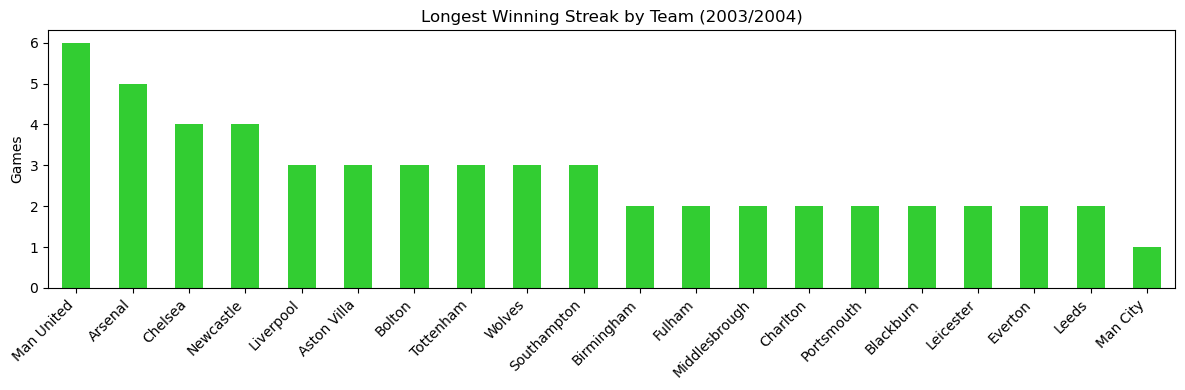

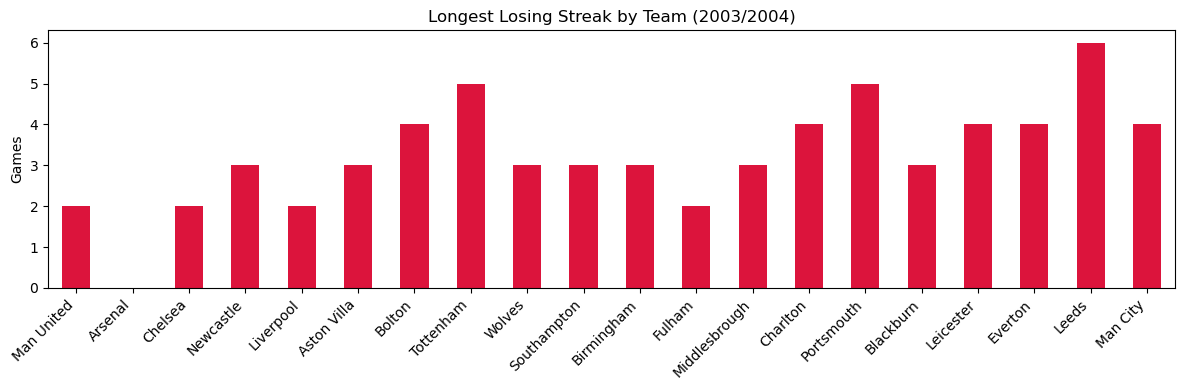

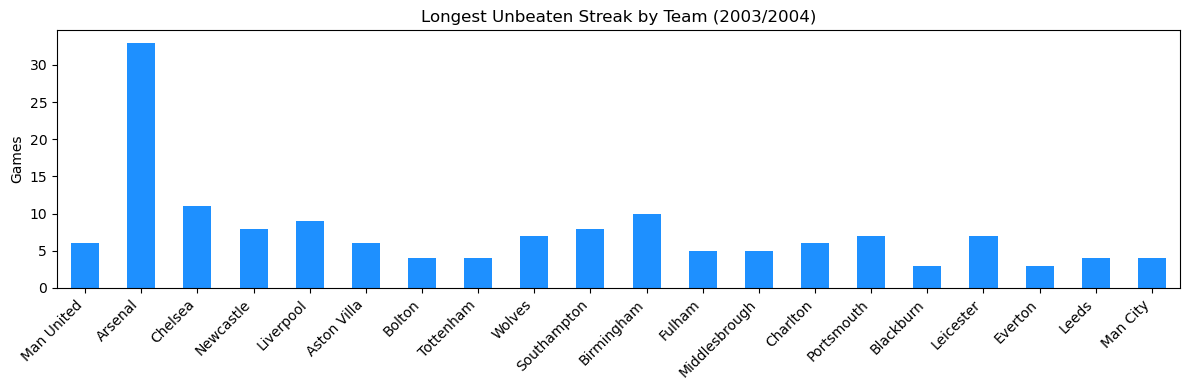

In [9]:
# Bar charts for longest streaks
plt.figure(figsize=(12,4))
streaks_df['Longest Win Streak'].plot(kind='bar', color='limegreen')
plt.ylabel('Games')
plt.title('Longest Winning Streak by Team (2003/2004)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
streaks_df['Longest Lose Streak'].plot(kind='bar', color='crimson')
plt.ylabel('Games')
plt.title('Longest Losing Streak by Team (2003/2004)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
streaks_df['Longest Unbeaten Streak'].plot(kind='bar', color='dodgerblue')
plt.ylabel('Games')
plt.title('Longest Unbeaten Streak by Team (2003/2004)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Home vs. Away Performance by Team

Let's compare the points earned at home and away for each team using a grouped bar chart.

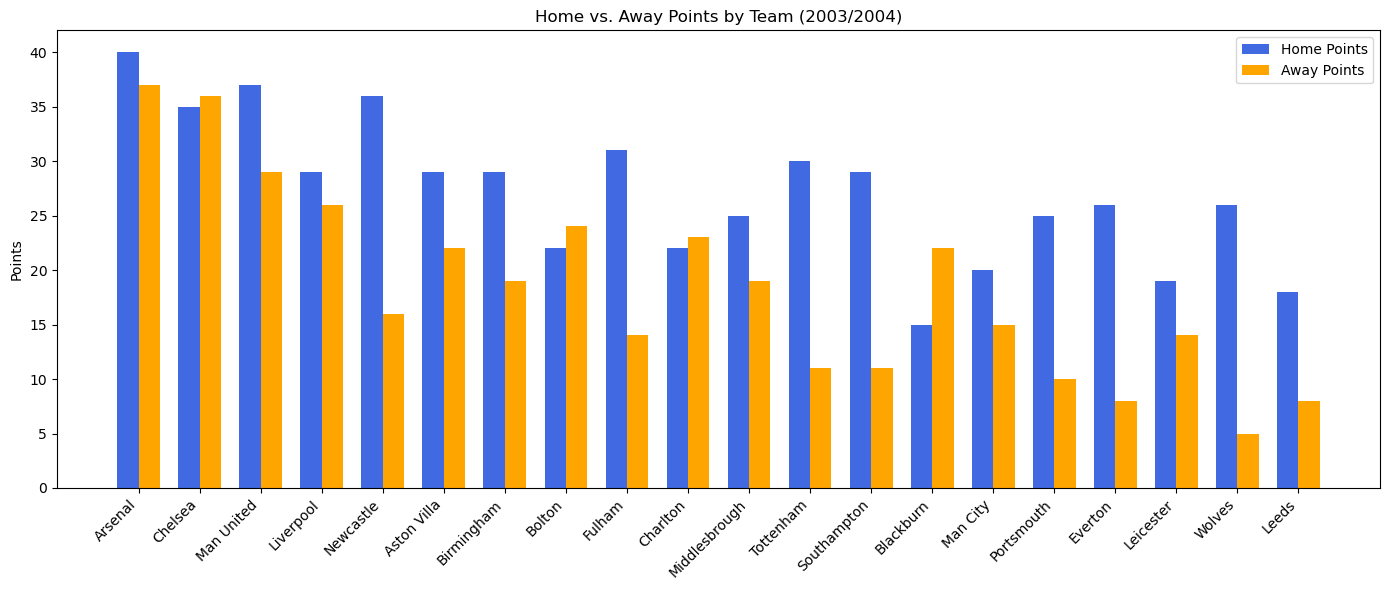

In [10]:
import numpy as np

# Prepare data for plotting
teams = league_table.index.tolist()
home_points = league_table.loc[teams, 'HomePoints']
away_points = league_table.loc[teams, 'AwayPoints']

x = np.arange(len(teams))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(14,6))
rects1 = ax.bar(x - width/2, home_points, width, label='Home Points', color='royalblue')
rects2 = ax.bar(x + width/2, away_points, width, label='Away Points', color='orange')

# Add labels, title, and custom x-axis tick labels
ax.set_ylabel('Points')
ax.set_title('Home vs. Away Points by Team (2003/2004)')
ax.set_xticks(x)
ax.set_xticklabels(teams, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

### Match Analysis

### Biggest Wins, Most Goals, and Surprising Upsets

This section identifies the biggest wins (by goal margin), matches with the most goals, and highlights some of the most surprising upsets based on league position.

In [11]:
# Biggest wins (by goal margin)
prem['GoalMargin'] = abs(prem['FTHG'] - prem['FTAG'])
biggest_wins = prem.sort_values('GoalMargin', ascending=False).head(5)
print('Biggest Wins (by goal margin):')
display(biggest_wins[['Date','HomeTeam','AwayTeam','FTHG','FTAG','GoalMargin']])

# Most goals in a match
prem['TotalGoals'] = prem['FTHG'] + prem['FTAG']
most_goals = prem.sort_values('TotalGoals', ascending=False).head(5)
print('Matches with Most Goals:')
display(most_goals[['Date','HomeTeam','AwayTeam','FTHG','FTAG','TotalGoals']])

# Most surprising upsets (lowest ranked team beating highest ranked team)
# We'll use final league_table for ranking
team_ranks = {team: rank+1 for rank, team in enumerate(league_table.index)}
def is_upset(row):
    if row['FTR'] == 'H':
        return team_ranks[row['HomeTeam']] > team_ranks[row['AwayTeam']]
    elif row['FTR'] == 'A':
        return team_ranks[row['AwayTeam']] > team_ranks[row['HomeTeam']]
    return False
upsets = prem[prem.apply(is_upset, axis=1)]

# Rank upsets by difference in league position
upsets['RankDiff'] = upsets.apply(lambda row: abs(team_ranks[row['HomeTeam']] - team_ranks[row['AwayTeam']]), axis=1)
most_surprising_upsets = upsets.sort_values('RankDiff', ascending=False).head(5)
print('Most Surprising Upsets (by league position difference):')
display(most_surprising_upsets[['Date','HomeTeam','AwayTeam','FTHG','FTAG','FTR','RankDiff']])

Biggest Wins (by goal margin):


,Date,HomeTeam,AwayTeam,FTHG,FTAG,GoalMargin
223,31/01/04,Leicester,Aston Villa,0,5,5
116,09/11/03,Chelsea,Newcastle,5,0,5
55,20/09/03,Wolves,Chelsea,0,5,5
114,08/11/03,Portsmouth,Leeds,6,1,5
206,11/01/04,Leicester,Chelsea,0,4,4


Matches with Most Goals:


,Date,HomeTeam,AwayTeam,FTHG,FTAG,TotalGoals
286,20/03/04,Middlesbrough,Birmingham,5,3,8
82,18/10/03,Man City,Bolton,6,2,8
257,22/02/04,Tottenham,Leicester,4,4,8
147,06/12/03,Tottenham,Wolves,5,2,7
200,10/01/04,Blackburn,Bolton,3,4,7


Most Surprising Upsets (by league position difference):


C:\Users\laura\AppData\Local\Temp\ipykernel_24220\341844247.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  upsets['RankDiff'] = upsets.apply(lambda row: abs(team_ranks[row['HomeTeam']] - team_ranks[row['AwayTeam']]), axis=1)


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,RankDiff
214,17/01/04,Wolves,Man United,1,0,H,16
84,18/10/03,Portsmouth,Liverpool,1,0,H,12
275,14/03/04,Man City,Man United,4,1,H,12
159,14/12/03,Leeds,Fulham,3,2,H,11
317,01/05/04,Blackburn,Man United,1,0,H,11


### Visualizing Biggest Wins, Most Goals

The following visualizations show the biggest wins (goal margin) and matches with the most goals.

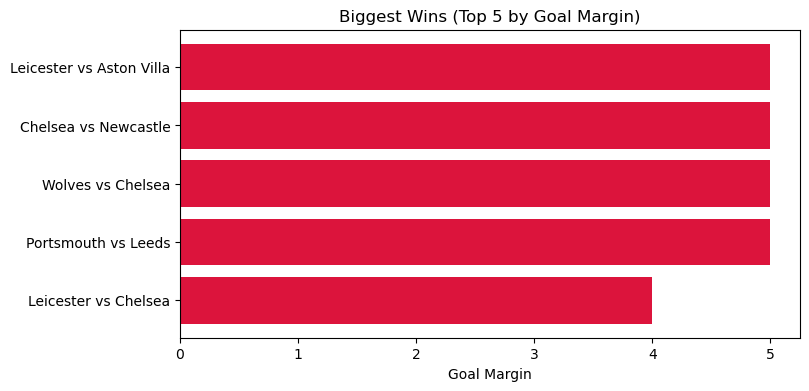

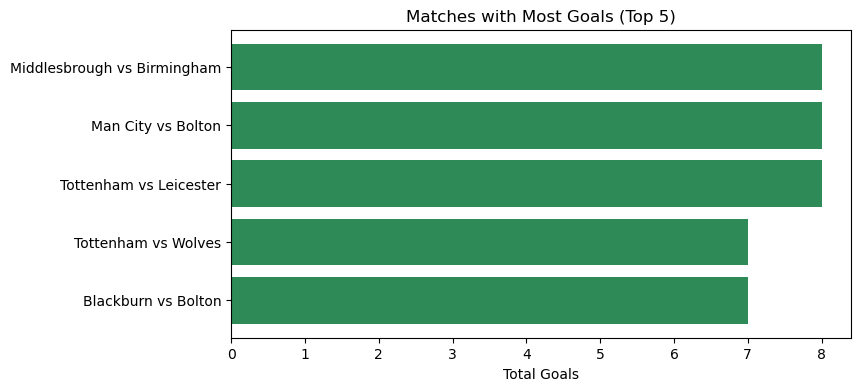

In [12]:
# Bar plot for biggest wins
plt.figure(figsize=(8,4))
plt.barh(biggest_wins['HomeTeam'] + ' vs ' + biggest_wins['AwayTeam'], biggest_wins['GoalMargin'], color='crimson')
plt.xlabel('Goal Margin')
plt.title('Biggest Wins (Top 5 by Goal Margin)')
plt.gca().invert_yaxis()
plt.show()

# Bar plot for most goals in a match
plt.figure(figsize=(8,4))
plt.barh(most_goals['HomeTeam'] + ' vs ' + most_goals['AwayTeam'], most_goals['TotalGoals'], color='seagreen')
plt.xlabel('Total Goals')
plt.title('Matches with Most Goals (Top 5)')
plt.gca().invert_yaxis()
plt.show()



### Heatmaps for Home/Away Results

The following code visualizes the results between each pair of teams as a heatmap, showing the number of home wins, away wins, and draws.

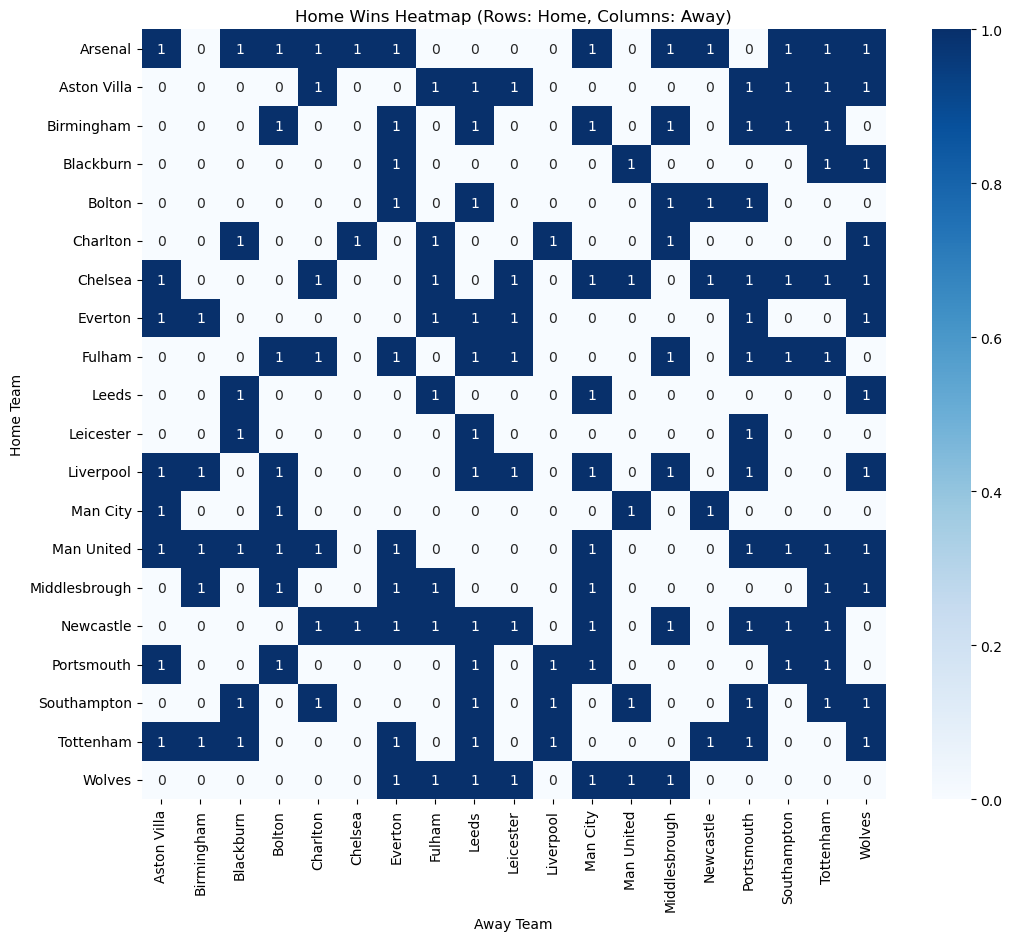

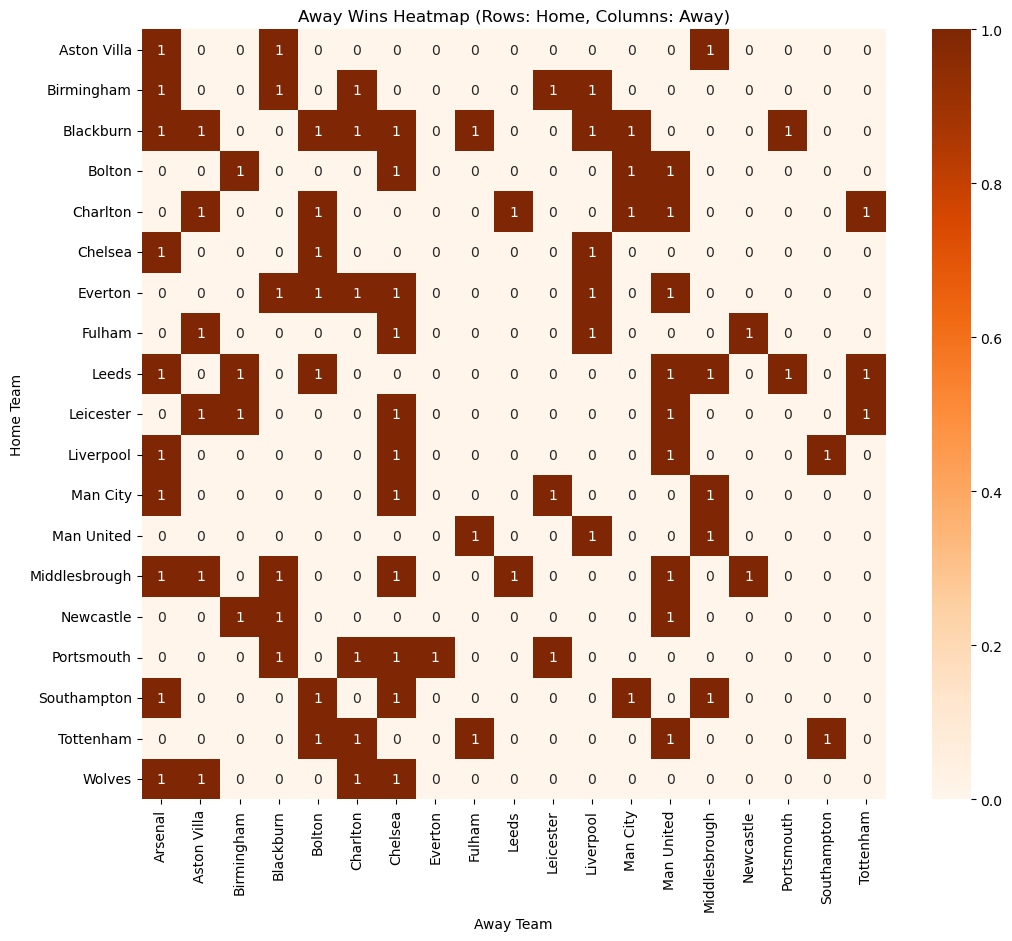

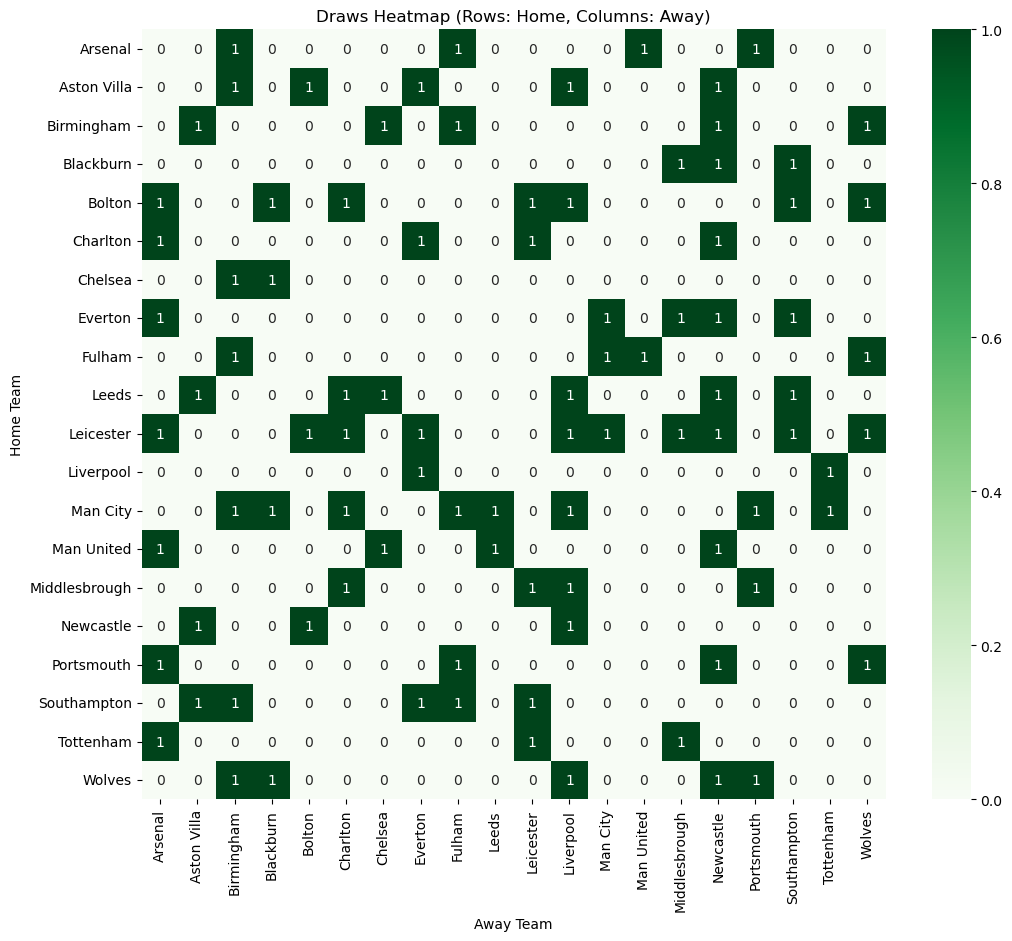

In [13]:
import seaborn as sns

# Create pivot tables for home wins, away wins, and draws
home_win_matrix = prem[prem['FTR']=='H'].pivot_table(index='HomeTeam', columns='AwayTeam', values='FTR', aggfunc='count', fill_value=0)
away_win_matrix = prem[prem['FTR']=='A'].pivot_table(index='HomeTeam', columns='AwayTeam', values='FTR', aggfunc='count', fill_value=0)
draw_matrix = prem[prem['FTR']=='D'].pivot_table(index='HomeTeam', columns='AwayTeam', values='FTR', aggfunc='count', fill_value=0)

plt.figure(figsize=(12,10))
sns.heatmap(home_win_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Home Wins Heatmap (Rows: Home, Columns: Away)')
plt.ylabel('Home Team')
plt.xlabel('Away Team')
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(away_win_matrix, annot=True, fmt='d', cmap='Oranges')
plt.title('Away Wins Heatmap (Rows: Home, Columns: Away)')
plt.ylabel('Home Team')
plt.xlabel('Away Team')
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(draw_matrix, annot=True, fmt='d', cmap='Greens')
plt.title('Draws Heatmap (Rows: Home, Columns: Away)')
plt.ylabel('Home Team')
plt.xlabel('Away Team')
plt.show()

### Correlation Between Goals Scored/Conceded and Final Position

This section analyzes and visualizes how goals scored and conceded relate to the final league position for each team.

Correlation (Goals Scored vs. Position): -0.76
Correlation (Goals Conceded vs. Position): 0.89


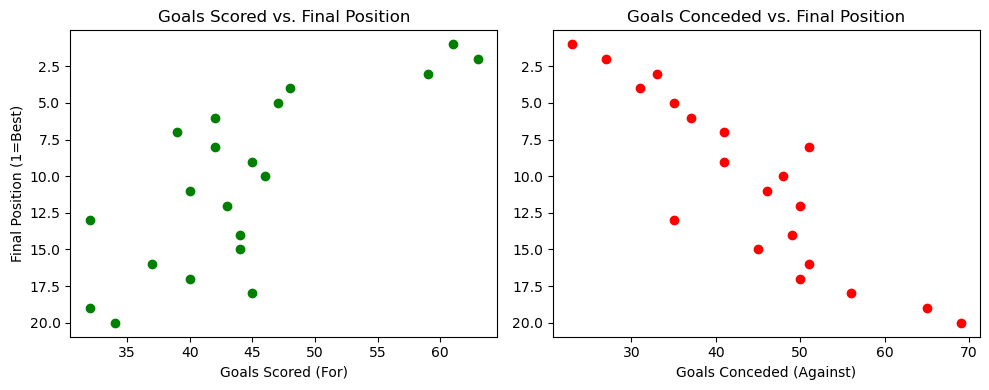

In [14]:
# Prepare data for correlation analysis
league_table['Position'] = range(1, len(league_table)+1)

# Correlation coefficients
corr_gf = league_table['GoalsFor'].corr(league_table['Position'])
corr_ga = league_table['GoalsAgainst'].corr(league_table['Position'])
print(f'Correlation (Goals Scored vs. Position): {corr_gf:.2f}')
print(f'Correlation (Goals Conceded vs. Position): {corr_ga:.2f}')

# Scatter plots
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(league_table['GoalsFor'], league_table['Position'], color='green')
plt.xlabel('Goals Scored (For)')
plt.ylabel('Final Position (1=Best)')
plt.title('Goals Scored vs. Final Position')
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
plt.scatter(league_table['GoalsAgainst'], league_table['Position'], color='red')
plt.xlabel('Goals Conceded (Against)')
plt.title('Goals Conceded vs. Final Position')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Further Analysis: Regression, Outliers, and Correlation Matrix

This section adds regression lines to the scatter plots, highlights outliers, and shows a correlation matrix for more league variables.

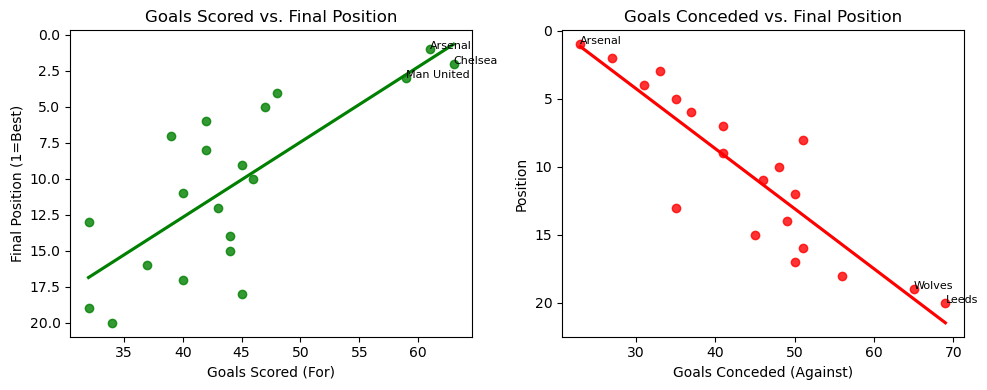

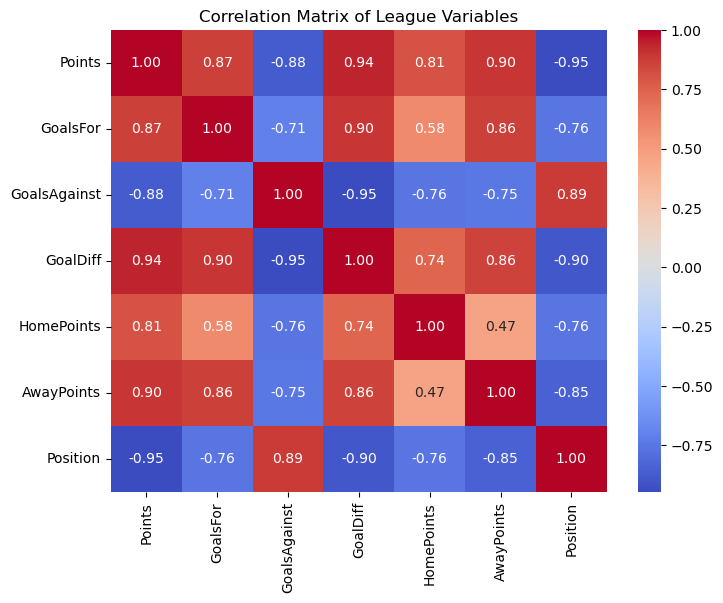

In [15]:
import seaborn as sns
from scipy.stats import linregress

# Regression and outlier annotation for Goals For
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.regplot(x=league_table['GoalsFor'], y=league_table['Position'], color='green', ci=None)
for i, row in league_table.iterrows():
    if abs(row['GoalsFor'] - league_table['GoalsFor'].mean()) > 1.5*league_table['GoalsFor'].std():
        plt.annotate(row.name, (row['GoalsFor'], row['Position']), fontsize=8, color='black')
plt.xlabel('Goals Scored (For)')
plt.ylabel('Final Position (1=Best)')
plt.title('Goals Scored vs. Final Position')
plt.gca().invert_yaxis()

# Regression and outlier annotation for Goals Against
plt.subplot(1,2,2)
sns.regplot(x=league_table['GoalsAgainst'], y=league_table['Position'], color='red', ci=None)
for i, row in league_table.iterrows():
    if abs(row['GoalsAgainst'] - league_table['GoalsAgainst'].mean()) > 1.5*league_table['GoalsAgainst'].std():
        plt.annotate(row.name, (row['GoalsAgainst'], row['Position']), fontsize=8, color='black')
plt.xlabel('Goals Conceded (Against)')
plt.title('Goals Conceded vs. Final Position')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Correlation matrix for more variables
corr_vars = league_table[['Points','GoalsFor','GoalsAgainst','GoalDiff','HomePoints','AwayPoints','Position']]
corr_matrix = corr_vars.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of League Variables')
plt.show()

### Clean Sheets


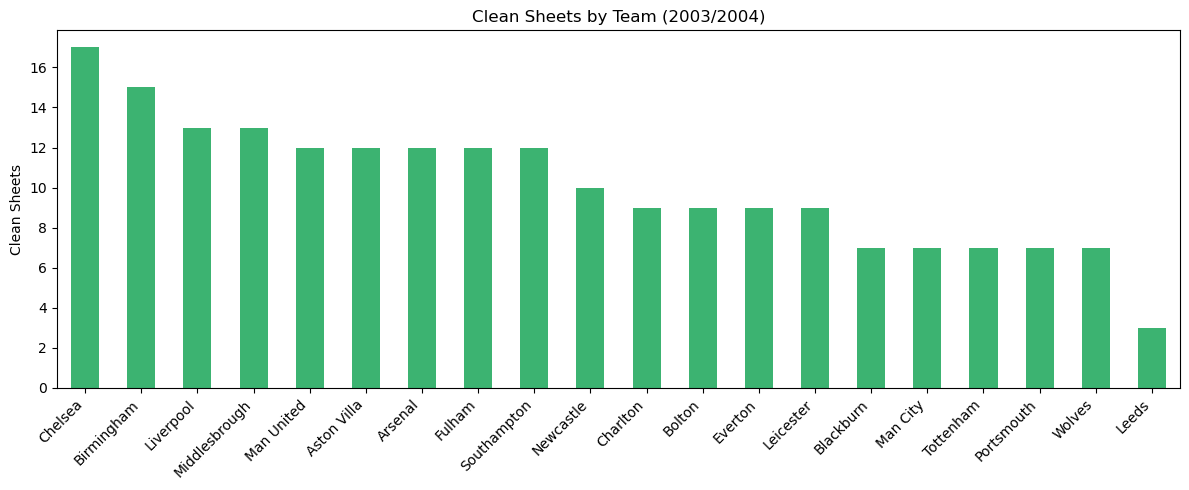

In [18]:
# Visualize clean sheets as a bar chart for each team
import matplotlib.pyplot as plt
import pandas as pd

# If clean_sheets already exists from previous cell, use it; otherwise, calculate it
if 'clean_sheets' in globals():
    cs = clean_sheets
elif 'prem' in globals() and 'HomeTeam' in prem.columns and 'AwayTeam' in prem.columns and 'FTHG' in prem.columns and 'FTAG' in prem.columns:
    home_clean_sheets = prem[prem['FTAG'] == 0]['HomeTeam'].value_counts()
    away_clean_sheets = prem[prem['FTHG'] == 0]['AwayTeam'].value_counts()
    cs = (home_clean_sheets + away_clean_sheets).sort_values(ascending=False)
else:
    cs = None

if cs is not None and not cs.empty:
    plt.figure(figsize=(12,5))
    cs.plot(kind='bar', color='mediumseagreen')
    plt.ylabel('Clean Sheets')
    plt.title('Clean Sheets by Team (2003/2004)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No clean sheet data available to plot.')

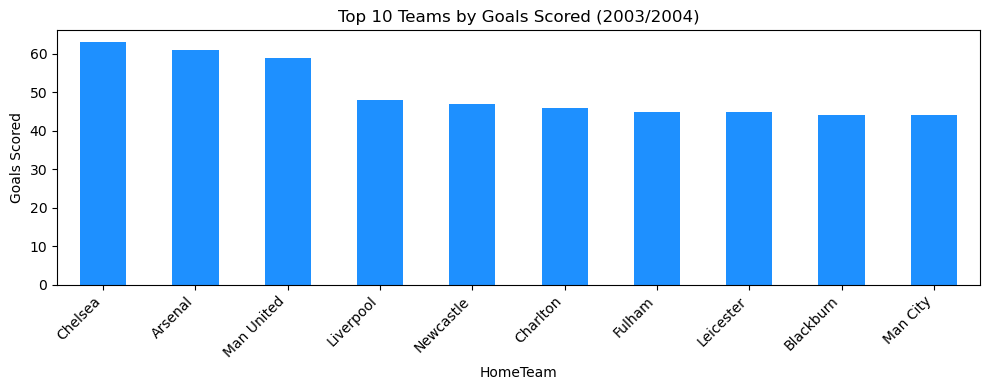

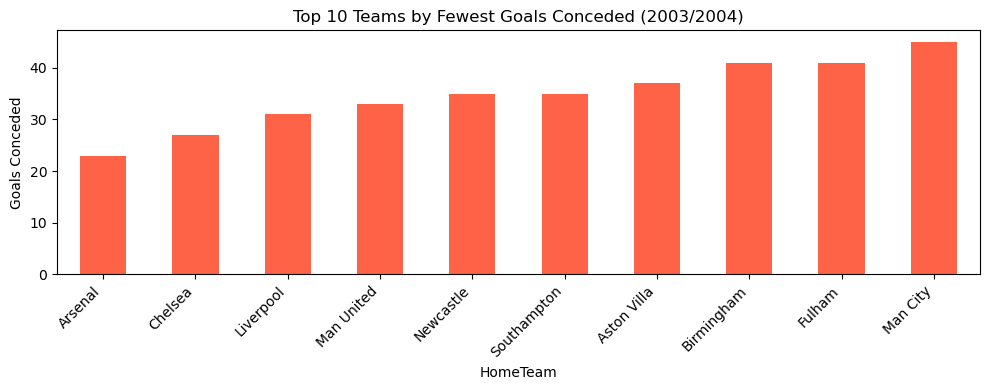

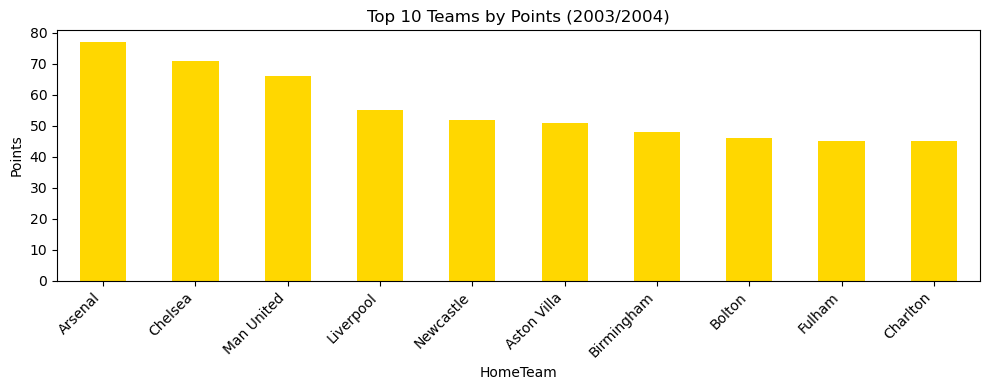

In [ ]:
# Bar chart: Top 10 teams by goals scored
if 'league_table' in globals():
    top_goals = league_table['GoalsFor'].sort_values(ascending=False).head(10)
    plt.figure(figsize=(10,4))
    top_goals.plot(kind='bar', color='dodgerblue')
    plt.ylabel('Goals Scored')
    plt.title('Top 10 Teams by Goals Scored (2003/2004)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No league table data available for goals scored.')

# Bar chart: Top 10 teams by fewest goals conceded
if 'league_table' in globals():
    fewest_conceded = league_table['GoalsAgainst'].sort_values(ascending=True).head(10)
    plt.figure(figsize=(10,4))
    fewest_conceded.plot(kind='bar', color='tomato')
    plt.ylabel('Goals Conceded')
    plt.title('Top 10 Teams by Fewest Goals Conceded (2003/2004)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No league table data available for goals conceded.')

# Bar chart: Top 10 teams by points
if 'league_table' in globals():
    top_points = league_table['Points'].sort_values(ascending=False).head(10)
    plt.figure(figsize=(10,4))
    top_points.plot(kind='bar', color='gold')
    plt.ylabel('Points')
    plt.title('Top 10 Teams by Points (2003/2004)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No league table data available for points.')

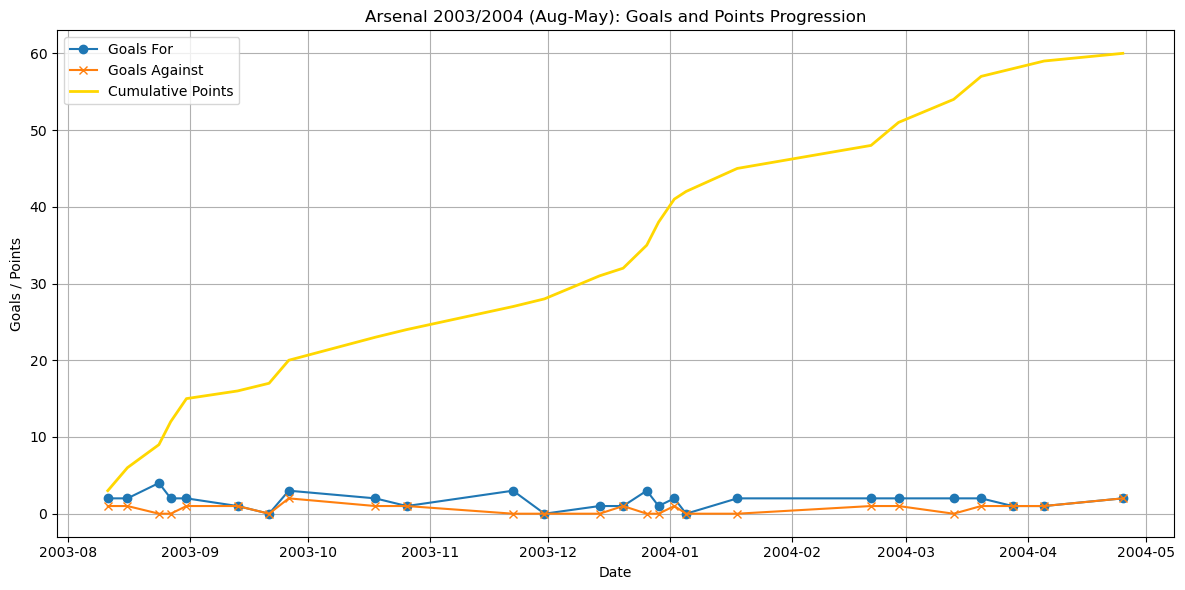

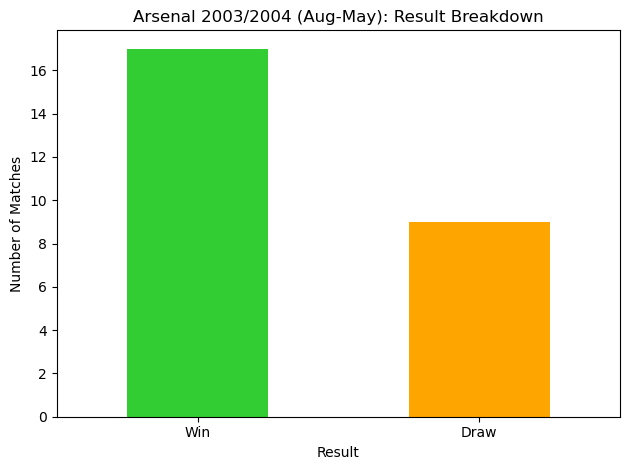

In [ ]:
# Arsenal: Visualize only matches from August 2003 to May 2004
import matplotlib.pyplot as plt
import pandas as pd

# Filter Arsenal matches for the correct date range
start_date = pd.Timestamp('2003-08-01')
end_date = pd.Timestamp('2004-05-31')
arsenal_season = arsenal_matches[(arsenal_matches['Date'] >= start_date) & (arsenal_matches['Date'] <= end_date)].copy()

# Cumulative points for filtered matches
points = []
cum_points = 0
for res in arsenal_season['Result']:
    if res == 'H':
        cum_points += 3
    elif res == 'D':
        cum_points += 1
    points.append(cum_points)

# Plot goals for/against and cumulative points for filtered matches
plt.figure(figsize=(12,6))
plt.plot(arsenal_season['Date'], arsenal_season['GF'], label='Goals For', marker='o')
plt.plot(arsenal_season['Date'], arsenal_season['GA'], label='Goals Against', marker='x')
plt.plot(arsenal_season['Date'], points, label='Cumulative Points', color='gold', linewidth=2)
plt.title('Arsenal 2003/2004 (Aug-May): Goals and Points Progression')
plt.xlabel('Date')
plt.ylabel('Goals / Points')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Bar chart of results (W/D/L) for filtered matches
result_map = {'H':'Win','D':'Draw','A':'Loss'}
arsenal_results = arsenal_season['Result'].map(result_map).value_counts()
arsenal_results.plot(kind='bar', color=['limegreen','orange','crimson'])
plt.title('Arsenal 2003/2004 (Aug-May): Result Breakdown')
plt.ylabel('Number of Matches')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\laura\AppData\Local\Temp\ipykernel_24220\25387641.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  arsenal_matches['Date'] = pd.to_datetime(arsenal_matches['Date'])


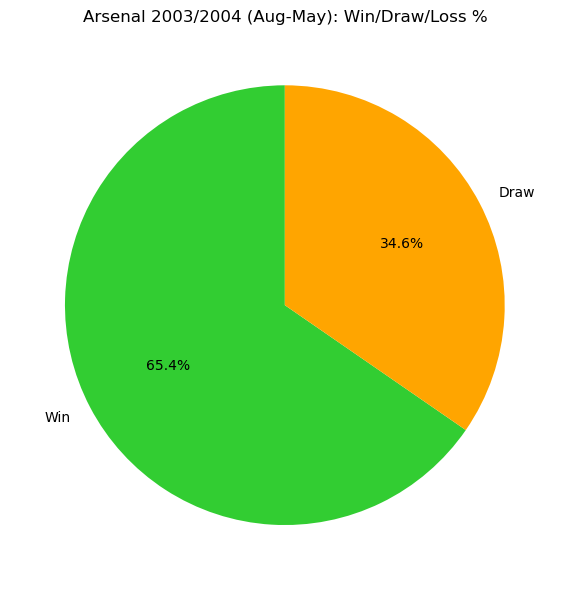

In [20]:
# Pie chart for Arsenal 2003/2004 (Aug-May): Win, Draw, Loss %
import matplotlib.pyplot as plt
import pandas as pd

# Filter all Arsenal matches (home or away)
arsenal_matches = prem[(prem['HomeTeam'] == 'Arsenal') | (prem['AwayTeam'] == 'Arsenal')].copy()
arsenal_matches['Date'] = pd.to_datetime(arsenal_matches['Date'])
arsenal_matches = arsenal_matches.sort_values('Date')

# Create columns for Arsenal goals for/against and result
def arsenal_stats(row):
	if row['HomeTeam'] == 'Arsenal':
		gf = row['FTHG']
		ga = row['FTAG']
		result = row['FTR']
	else:
		gf = row['FTAG']
		ga = row['FTHG']
		# Reverse result for away
		if row['FTR'] == 'H':
			result = 'A'
		elif row['FTR'] == 'A':
			result = 'H'
		else:
			result = 'D'
	return pd.Series({'GF': gf, 'GA': ga, 'Result': result})

arsenal_matches[['GF','GA','Result']] = arsenal_matches.apply(arsenal_stats, axis=1)

# Filter Arsenal matches for the correct date range
start_date = pd.Timestamp('2003-08-01')
end_date = pd.Timestamp('2004-05-31')
arsenal_season = arsenal_matches[(arsenal_matches['Date'] >= start_date) & (arsenal_matches['Date'] <= end_date)].copy()

# Use the filtered arsenal_season DataFrame from previous analysis
result_map = {'H':'Win','D':'Draw','A':'Loss'}
arsenal_results = arsenal_season['Result'].map(result_map).value_counts()

# Pie chart
plt.figure(figsize=(6,6))
arsenal_results.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['limegreen','orange','crimson'])
plt.title('Arsenal 2003/2004 (Aug-May): Win/Draw/Loss %')
plt.ylabel('')
plt.tight_layout()
plt.show()

C:\Users\laura\AppData\Local\Temp\ipykernel_43852\653858408.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wolves_matches['Date'] = pd.to_datetime(wolves_matches['Date'])


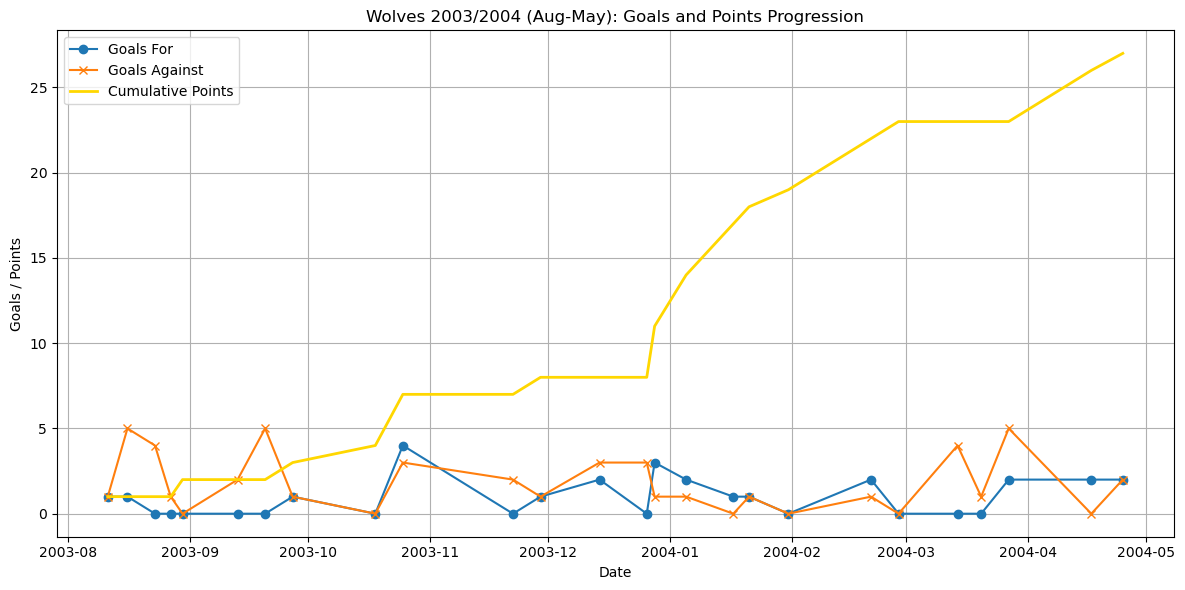

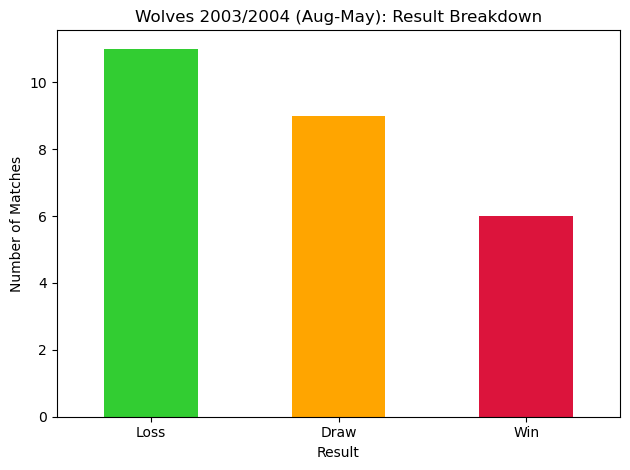

In [ ]:
# Wolves: Visualize only matches from August 2003 to May 2004
import matplotlib.pyplot as plt
import pandas as pd

# Filter all Wolves matches (home or away)
wolves_matches = prem[(prem['HomeTeam'] == 'Wolves') | (prem['AwayTeam'] == 'Wolves')].copy()
wolves_matches['Date'] = pd.to_datetime(wolves_matches['Date'])
wolves_matches = wolves_matches.sort_values('Date')

# Create columns for Wolves goals for/against and result
def wolves_stats(row):
    if row['HomeTeam'] == 'Wolves':
        gf = row['FTHG']
        ga = row['FTAG']
        result = row['FTR']
    else:
        gf = row['FTAG']
        ga = row['FTHG']
        # Reverse result for away
        if row['FTR'] == 'H':
            result = 'A'
        elif row['FTR'] == 'A':
            result = 'H'
        else:
            result = 'D'
    return pd.Series({'GF': gf, 'GA': ga, 'Result': result})

wolves_matches[['GF','GA','Result']] = wolves_matches.apply(wolves_stats, axis=1)

# Filter Wolves matches for the correct date range
start_date = pd.Timestamp('2003-08-01')
end_date = pd.Timestamp('2004-05-31')
wolves_season = wolves_matches[(wolves_matches['Date'] >= start_date) & (wolves_matches['Date'] <= end_date)].copy()

# Cumulative points for filtered matches
points = []
cum_points = 0
for res in wolves_season['Result']:
    if res == 'H':
        cum_points += 3
    elif res == 'D':
        cum_points += 1
    points.append(cum_points)

# Plot goals for/against and cumulative points for filtered matches
plt.figure(figsize=(12,6))
plt.plot(wolves_season['Date'], wolves_season['GF'], label='Goals For', marker='o')
plt.plot(wolves_season['Date'], wolves_season['GA'], label='Goals Against', marker='x')
plt.plot(wolves_season['Date'], points, label='Cumulative Points', color='gold', linewidth=2)
plt.title('Wolves 2003/2004 (Aug-May): Goals and Points Progression')
plt.xlabel('Date')
plt.ylabel('Goals / Points')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Bar chart of results (W/D/L) for filtered matches
result_map = {'H':'Win','D':'Draw','A':'Loss'}
wolves_results = wolves_season['Result'].map(result_map).value_counts()
wolves_results.plot(kind='bar', color=['limegreen','orange','crimson'])
plt.title('Wolves 2003/2004 (Aug-May): Result Breakdown')
plt.ylabel('Number of Matches')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\laura\AppData\Local\Temp\ipykernel_24220\1375054264.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wolves_matches['Date'] = pd.to_datetime(wolves_matches['Date'])


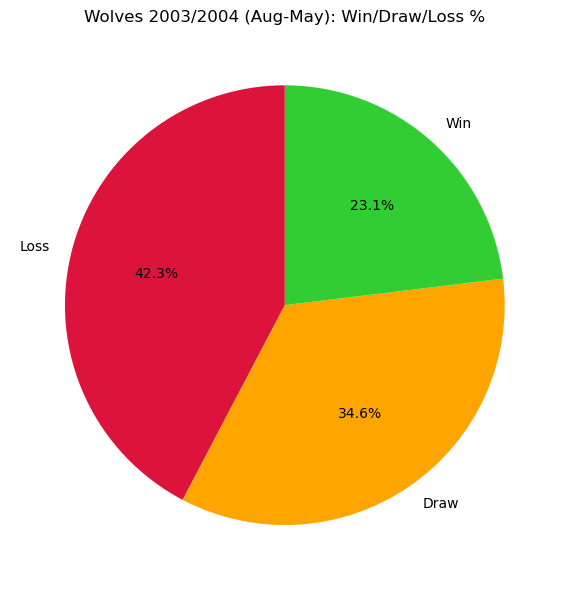

In [26]:
# Pie chart for Wolves 2003/2004 (Aug-May): Win, Draw, Loss %
import matplotlib.pyplot as plt
import pandas as pd

# Filter all Wolves matches (home or away)
wolves_matches = prem[(prem['HomeTeam'] == 'Wolves') | (prem['AwayTeam'] == 'Wolves')].copy()
wolves_matches['Date'] = pd.to_datetime(wolves_matches['Date'])
wolves_matches = wolves_matches.sort_values('Date')

# Create columns for Wolves goals for/against and result
def wolves_stats(row):
	if row['HomeTeam'] == 'Wolves':
		gf = row['FTHG']
		ga = row['FTAG']
		result = row['FTR']
	else:
		gf = row['FTAG']
		ga = row['FTHG']
		# Reverse result for away
		if row['FTR'] == 'H':
			result = 'A'
		elif row['FTR'] == 'A':
			result = 'H'
		else:
			result = 'D'
	return pd.Series({'GF': gf, 'GA': ga, 'Result': result})

wolves_matches[['GF','GA','Result']] = wolves_matches.apply(wolves_stats, axis=1)

# Filter Wolves matches for the correct date range
start_date = pd.Timestamp('2003-08-01')
end_date = pd.Timestamp('2004-05-31')
wolves_season = wolves_matches[(wolves_matches['Date'] >= start_date) & (wolves_matches['Date'] <= end_date)].copy()

result_map = {'H':'Win','D':'Draw','A':'Loss'}
wolves_results = wolves_season['Result'].map(result_map).value_counts()
plt.figure(figsize=(6,6))
wolves_results.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['crimson','orange','limegreen'])
plt.title('Wolves 2003/2004 (Aug-May): Win/Draw/Loss %')
plt.ylabel('')
plt.tight_layout()
plt.show()


C:\Users\laura\AppData\Local\Temp\ipykernel_24220\1306828105.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  leeds_matches['Date'] = pd.to_datetime(leeds_matches['Date'])


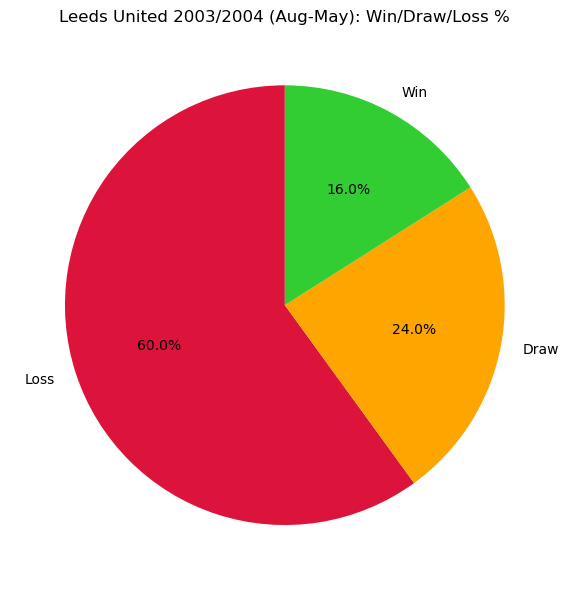

In [27]:

import matplotlib.pyplot as plt
import pandas as pd

# Filter all Leeds matches (home or away)
leeds_matches = prem[(prem['HomeTeam'] == 'Leeds') | (prem['AwayTeam'] == 'Leeds')].copy()
leeds_matches['Date'] = pd.to_datetime(leeds_matches['Date'])
leeds_matches = leeds_matches.sort_values('Date')

# Create columns for Leeds goals for/against and result
def leeds_stats(row):
	if row['HomeTeam'] == 'Leeds':
		gf = row['FTHG']
		ga = row['FTAG']
		result = row['FTR']
	else:
		gf = row['FTAG']
		ga = row['FTHG']
		# Reverse result for away
		if row['FTR'] == 'H':
			result = 'A'
		elif row['FTR'] == 'A':
			result = 'H'
		else:
			result = 'D'
	return pd.Series({'GF': gf, 'GA': ga, 'Result': result})

leeds_matches[['GF','GA','Result']] = leeds_matches.apply(leeds_stats, axis=1)

# Filter Leeds matches for the correct date range
start_date = pd.Timestamp('2003-08-01')
end_date = pd.Timestamp('2004-05-31')
leeds_season = leeds_matches[(leeds_matches['Date'] >= start_date) & (leeds_matches['Date'] <= end_date)].copy()

# Pie chart for Leeds United 2003/2004 (Aug-May): Win, Draw, Loss %
result_map = {'H':'Win','D':'Draw','A':'Loss'}
leeds_results = leeds_season['Result'].map(result_map).value_counts()
plt.figure(figsize=(6,6))
leeds_results.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['crimson','orange','limegreen'])
plt.title('Leeds United 2003/2004 (Aug-May): Win/Draw/Loss %')
plt.ylabel('')
plt.tight_layout()
plt.show()

C:\Users\laura\AppData\Local\Temp\ipykernel_43852\1298449363.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  leeds_matches['Date'] = pd.to_datetime(leeds_matches['Date'])


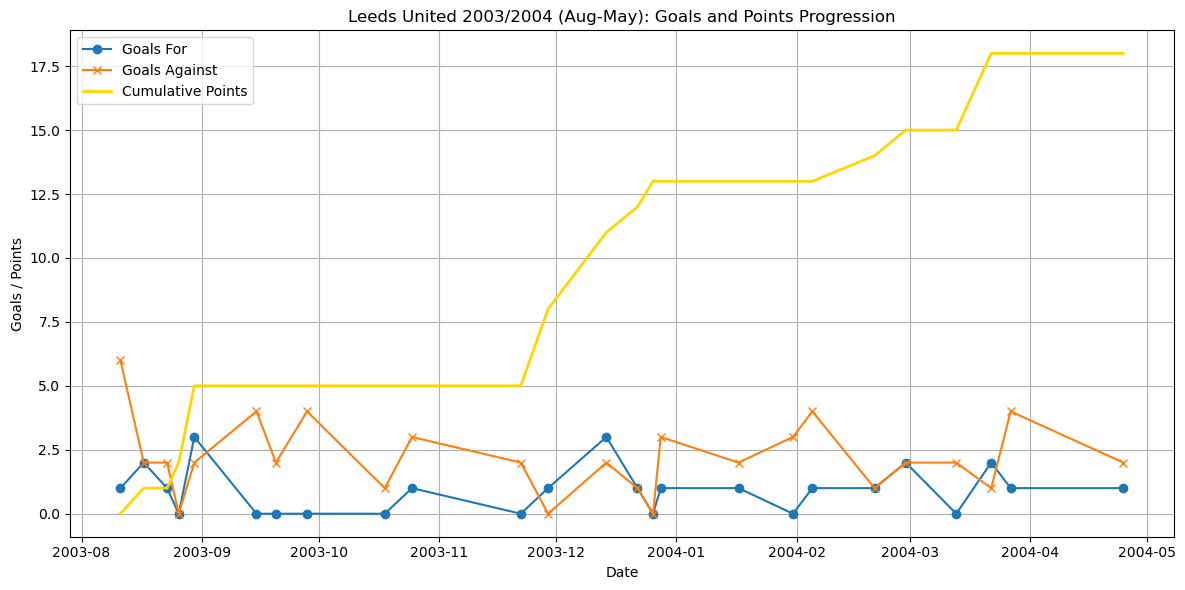

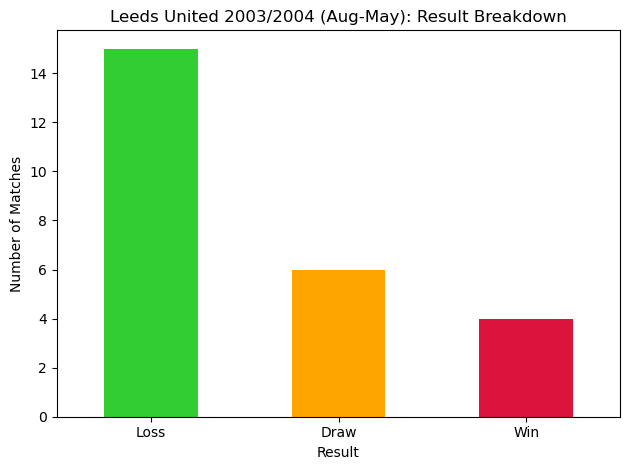

In [ ]:
# Leeds United: Visualize only matches from August 2003 to May 2004
import matplotlib.pyplot as plt
import pandas as pd

# Filter all Leeds matches (home or away)
leeds_matches = prem[(prem['HomeTeam'] == 'Leeds') | (prem['AwayTeam'] == 'Leeds')].copy()
leeds_matches['Date'] = pd.to_datetime(leeds_matches['Date'])
leeds_matches = leeds_matches.sort_values('Date')

# Create columns for Leeds goals for/against and result
def leeds_stats(row):
    if row['HomeTeam'] == 'Leeds':
        gf = row['FTHG']
        ga = row['FTAG']
        result = row['FTR']
    else:
        gf = row['FTAG']
        ga = row['FTHG']
        # Reverse result for away
        if row['FTR'] == 'H':
            result = 'A'
        elif row['FTR'] == 'A':
            result = 'H'
        else:
            result = 'D'
    return pd.Series({'GF': gf, 'GA': ga, 'Result': result})

leeds_matches[['GF','GA','Result']] = leeds_matches.apply(leeds_stats, axis=1)

# Filter Leeds matches for the correct date range
start_date = pd.Timestamp('2003-08-01')
end_date = pd.Timestamp('2004-05-31')
leeds_season = leeds_matches[(leeds_matches['Date'] >= start_date) & (leeds_matches['Date'] <= end_date)].copy()

# Cumulative points for filtered matches
points = []
cum_points = 0
for res in leeds_season['Result']:
    if res == 'H':
        cum_points += 3
    elif res == 'D':
        cum_points += 1
    points.append(cum_points)

# Plot goals for/against and cumulative points for filtered matches
plt.figure(figsize=(12,6))
plt.plot(leeds_season['Date'], leeds_season['GF'], label='Goals For', marker='o')
plt.plot(leeds_season['Date'], leeds_season['GA'], label='Goals Against', marker='x')
plt.plot(leeds_season['Date'], points, label='Cumulative Points', color='gold', linewidth=2)
plt.title('Leeds United 2003/2004 (Aug-May): Goals and Points Progression')
plt.xlabel('Date')
plt.ylabel('Goals / Points')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Bar chart of results (W/D/L) for filtered matches
result_map = {'H':'Win','D':'Draw','A':'Loss'}
leeds_results = leeds_season['Result'].map(result_map).value_counts()
leeds_results.plot(kind='bar', color=['limegreen','orange','crimson'])
plt.title('Leeds United 2003/2004 (Aug-May): Result Breakdown')
plt.ylabel('Number of Matches')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()